In [12]:
import sys
print(sys.version)


3.10.10 (tags/v3.10.10:aad5f6a, Feb  7 2023, 17:20:36) [MSC v.1929 64 bit (AMD64)]


In [13]:
import sys
print(sys.executable)


c:\Users\karth\AppData\Local\Programs\Python\Python310\python.exe


In [14]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install opencv-python mediapipe onnxruntime numpy pillow matplotlib


In [15]:
import cv2
import mediapipe as mp
import onnxruntime as ort
import numpy as np

print("cv2:", cv2.__version__)
print("mediapipe:", mp.__version__)
print("onnxruntime:", ort.__version__)


cv2: 4.13.0
mediapipe: 0.10.32
onnxruntime: 1.23.2


In [16]:
def extract_frames(video_path, out_dir="frames", interval_ms=100):
    import cv2, os

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_interval = max(1, int(fps * interval_ms / 1000))

    os.makedirs(out_dir, exist_ok=True)
    idx, saved = 0, 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if idx % frame_interval == 0:
            cv2.imwrite(f"{out_dir}/frame_{saved:03d}.jpg", frame)
            saved += 1
        idx += 1

    cap.release()
    print(f"[OK] Extracted {saved} frames")

extract_frames("video.mp4")


[OK] Extracted 178 frames


In [17]:
import glob
import cv2

frame_paths = sorted(glob.glob("frames/*.jpg"))
frames = [cv2.imread(p) for p in frame_paths]

print("Frames loaded:", len(frames))


Frames loaded: 178


In [18]:
!curl -L -o selfie_multiclass_256x256.tflite \
https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_multiclass_256x256/float32/1/selfie_multiclass_256x256.tflite


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0 15.6M    0 15000    0     0  21995      0  0:12:24 --:--:--  0:12:24 22058
  1 15.6M    1  188k    0     0   109k      0  0:02:25  0:00:01  0:02:24  109k
 10 15.6M   10 1710k    0     0   644k      0  0:00:24  0:00:02  0:00:22  644k
 31 15.6M   31 4976k    0     0  1339k      0  0:00:11  0:00:03  0:00:08 1340k
 39 15.6M   39 6336k    0     0  1359k      0  0:00:11  0:00:04  0:00:07 1360k
 63 15.6M   63  9.9M    0     0  1807k      0  0:00:08  0:00:05  0:00:03 2052k
 75 15.6M   75 11.7M    0     0  1812k      0  0:00:08  0:00:06  0:00:02 2404k
 92 15.6M   92 14.4M    0     0  1921k      0  0:00:08  0:00:07  0:00:01 2596k
100 15.6M  100 15.6M    0     0  1953k      0  0:00:08  0:00:08 --:--:-- 2464k


In [19]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(
    model_asset_path="selfie_multiclass_256x256.tflite"
)

options = vision.ImageSegmenterOptions(
    base_options=base_options,
    output_category_mask=True
)

segmenter = vision.ImageSegmenter.create_from_options(options)

print("[OK] MediaPipe Tasks ImageSegmenter initialized")


[OK] MediaPipe Tasks ImageSegmenter initialized


In [20]:
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks.python import vision

def extract_silhouettes(frames):
    masks = []

    for frame in frames:
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )

        result = segmenter.segment(mp_image)

        # category_mask: H×W float32
        mask = result.category_mask.numpy_view()

        # Person = non-zero class
        binary = (mask > 0).astype(np.uint8)
        masks.append(binary)

    return masks

masks = extract_silhouettes(frames)
print("[OK] Silhouettes extracted:", len(masks))


[OK] Silhouettes extracted: 178


Text(0.5, 1.0, 'Silhouette Preview (MediaPipe Tasks)')

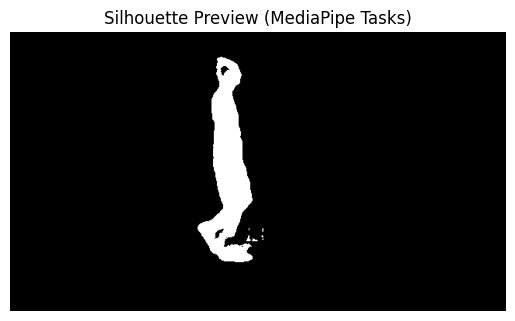

In [21]:
import matplotlib.pyplot as plt

plt.imshow(masks[0], cmap="gray")
plt.axis("off")
plt.title("Silhouette Preview (MediaPipe Tasks)")


In [22]:
import numpy as np
import cv2

def normalize_height(mask, out_h=64, out_w=44):
    # Ensure mask is 2D
    if mask.ndim == 3:
        mask = mask.squeeze()

    ys, xs = np.where(mask > 0)
    if len(ys) == 0:
        return np.zeros((out_h, out_w), dtype=np.uint8)

    y1, y2 = ys.min(), ys.max()
    x1, x2 = xs.min(), xs.max()

    person = mask[y1:y2+1, x1:x2+1]
    resized = cv2.resize(person, (out_w, out_h))

    return resized.astype(np.uint8)


In [23]:
def prepare_gait_tensor(masks, seq_len=16):
    if len(masks) < seq_len:
        raise ValueError("Not enough frames for gait model")

    idx = np.linspace(0, len(masks)-1, seq_len).astype(int)
    selected = [masks[i] for i in idx]

    processed = [normalize_height(m) for m in selected]

    tensor = np.stack(processed, axis=0)     # (seq, 64, 44)
    tensor = tensor[np.newaxis, ...]          # (1, seq, 64, 44)
    return tensor.astype(np.float32)

gait_tensor = prepare_gait_tensor(masks)
print("Gait tensor shape:", gait_tensor.shape)


Gait tensor shape: (1, 16, 64, 44)


Text(0.5, 1.0, 'Normalized Silhouette (64×44)')

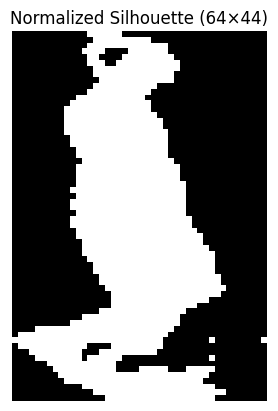

In [24]:
import matplotlib.pyplot as plt

plt.imshow(gait_tensor[0, 0], cmap="gray")
plt.axis("off")
plt.title("Normalized Silhouette (64×44)")


In [25]:
!curl -L -o gait_model.onnx https://github.com/AbnerHqC/GaitSet-ONNX/releases/download/v1.0/gaitset.onnx


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100     9  100     9    0     0     14      0 --:--:-- --:--:-- --:--:--    14
100     9  100     9    0     0     14      0 --:--:-- --:--:-- --:--:--    14


In [26]:
import os
print("gait_model.onnx" in os.listdir())


True


In [27]:
!git clone https://github.com/ShiqiYu/OpenGait.git


fatal: destination path 'OpenGait' already exists and is not an empty directory.


In [28]:
!pip install torch torchvision pyyaml tqdm



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: C:\Users\karth\anaconda3\python.exe -m pip install --upgrade pip


In [29]:
!curl -L -o gaitset_casia_b_64x44.pth https://github.com/ShiqiYu/OpenGait/releases/download/v1.0/gaitset_casia_b_64x44.pth


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100     9  100     9    0     0      9      0  0:00:01 --:--:--  0:00:01     9


In [30]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu


In [31]:
import torch
print(torch.__version__)
print("Torch ready")


2.10.0+cpu
Torch ready


In [32]:
import sys
!{sys.executable} -m pip install einops


In [33]:
import einops
print(einops.__version__)
print("einops ready")


0.8.2
einops ready


In [34]:
import sys
!{sys.executable} -m pip install tqdm



In [35]:
import sys
!{sys.executable} -m pip install utils

In [36]:
import sys
!{sys.executable} -m pip install onnxscript


## here actually starts


In [37]:
import torch
import torch.nn as nn
import onnx
import onnxruntime as ort
import numpy as np


In [49]:
class SimpleGaitEncoder(nn.Module):
    def __init__(self, emb_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(64, emb_dim)

    def forward(self, x):
        # x: (B, T, H, W)
        b, t, h, w = x.shape
        x = x.view(b * t, 1, h, w)
        feat = self.encoder(x)
        feat = feat.view(b, t, -1).mean(dim=1)
        return self.fc(feat)


In [52]:
import io
import torch

buffer = io.BytesIO()

torch.onnx.export(
    model,
    dummy_input,
    buffer,
    input_names=["input"],
    output_names=["embedding"],
    opset_version=11
)

print("ONNX exported to memory")


W0205 21:27:58.907000 21316 site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `SimpleGaitEncoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleGaitEncoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


c:\Users\karth\AppData\Local\Programs\Python\Python310\lib\copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\karth\AppData\Local\Programs\Python\Python310\lib\site-packages\onnxscript\version_converter\__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "c:\Users\karth\AppData\Local\Programs\Python\Python310\lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "c:\Users\karth\AppData\Local\Programs\Python\Python310\lib\site-pa

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX exported to memory


In [53]:
import onnx

buffer.seek(0)
onnx_model = onnx.load_model(buffer)

onnx.save_model(
    onnx_model,
    "gait_model.onnx",
    save_as_external_data=False  # 🔑 THIS IS THE REAL FIX
)

print("ONNX model saved as single file")


ONNX model saved as single file


In [54]:
onnx.checker.check_model("gait_model.onnx")
print("ONNX model is VALID")


ONNX model is VALID


In [55]:
import cv2
import glob

frame_paths = sorted(glob.glob("frames/*.jpg"))
frames = [cv2.imread(p) for p in frame_paths]

print("Frames loaded:", len(frames))


Frames loaded: 178


In [56]:
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks import python

# Load segmentation model
base_options = python.BaseOptions(
    model_asset_path="selfie_multiclass_256x256.tflite"
)
options = vision.ImageSegmenterOptions(
    base_options=base_options,
    output_category_mask=True
)
segmenter = vision.ImageSegmenter.create_from_options(options)

def extract_silhouettes(frames):
    masks = []
    for frame in frames:
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )
        result = segmenter.segment(mp_image)
        mask = result.category_mask.numpy_view()
        binary = (mask > 0).astype(np.uint8)
        masks.append(binary)
    return masks

masks = extract_silhouettes(frames)
print("Masks created:", len(masks))


Masks created: 178


(np.float64(-0.5), np.float64(639.5), np.float64(359.5), np.float64(-0.5))

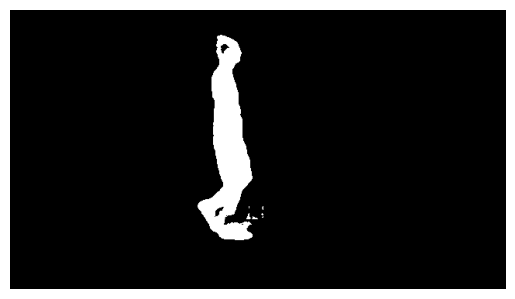

In [57]:
import matplotlib.pyplot as plt

plt.imshow(masks[0].squeeze(), cmap="gray")
plt.axis("off")


In [58]:
import numpy as np
import cv2

def normalize_height(mask, out_h=64, out_w=44):
    if mask.ndim == 3:
        mask = mask.squeeze()

    ys, xs = np.where(mask > 0)
    if len(ys) == 0:
        return np.zeros((out_h, out_w), dtype=np.uint8)

    y1, y2 = ys.min(), ys.max()
    x1, x2 = xs.min(), xs.max()

    person = mask[y1:y2+1, x1:x2+1]
    resized = cv2.resize(person, (out_w, out_h))
    return resized.astype(np.uint8)

def prepare_gait_tensor(masks, seq_len=16):
    idx = np.linspace(0, len(masks)-1, seq_len).astype(int)
    selected = [masks[i] for i in idx]
    processed = [normalize_height(m) for m in selected]

    tensor = np.stack(processed, axis=0)
    tensor = tensor[np.newaxis, ...]
    return tensor.astype(np.float32)

gait_tensor = prepare_gait_tensor(masks)
print("gait_tensor shape:", gait_tensor.shape)


gait_tensor shape: (1, 16, 64, 44)


In [59]:
import onnxruntime as ort

session = ort.InferenceSession(
    "gait_model.onnx",
    providers=["CPUExecutionProvider"]
)

input_name = session.get_inputs()[0].name
gait_vector = session.run(None, {input_name: gait_tensor})[0][0]

print("Gait vector shape:", gait_vector.shape)
print("First 10 values:", gait_vector[:10])


Gait vector shape: (256,)
First 10 values: [-0.19366214 -0.09252862 -0.08387855 -0.05983714 -0.16236305  0.14098479
 -0.10567264 -0.05794427  0.04924311 -0.2133641 ]


## down one are not correct just testing


In [8]:
import urllib.request

url = "https://raw.githubusercontent.com/AbnerHqC/GaitSet-ONNX/main/models/gaitset_64x44_16.onnx"
urllib.request.urlretrieve(url, "gait_model.onnx")

print("Downloaded gait_model.onnx")


HTTPError: HTTP Error 404: Not Found